# SemEval 2025 Task 9: The Food Hazard Detection Challenge

### Data Loading Process

#### This script downloads and loads the training, validation, and test datasets for the Food Hazard Detection Challenge.

- **Import Dependencies:** The `pandas` library is imported for data handling.
- **Download Data:** The `wget` command retrieves CSV files from the GitHub repository, containing labeled incident reports.
- **Load Data:** Each dataset (training, validation, and test) is loaded into a `pandas.DataFrame`, with the first column set as the index.
- **Print Data Shapes:** The script outputs the dimensions (rows, columns) of each dataset to confirm successful loading.

In [18]:
import pandas as pd

# Download training data (labeled):
!wget https://raw.githubusercontent.com/food-hazard-detection-semeval-2025/food-hazard-detection-semeval-2025.github.io/refs/heads/main/data/incidents_train.csv

# Load training data:
train_df = pd.read_csv('incidents_train.csv', index_col=0)

# Download validation data (labeled):
!wget https://raw.githubusercontent.com/food-hazard-detection-semeval-2025/food-hazard-detection-semeval-2025.github.io/refs/heads/main/data/incidents_valid.csv

# Load validation data:
valid_df = pd.read_csv('incidents_valid.csv', index_col=0)

# Download test data (labeled):
!wget https://raw.githubusercontent.com/food-hazard-detection-semeval-2025/food-hazard-detection-semeval-2025.github.io/refs/heads/main/data/incidents_test.csv

# Load test data:
test_df = pd.read_csv('incidents_test.csv', index_col=0)

print(f"Loaded Data: Train={train_df.shape}, Validation={valid_df.shape}, Test={test_df.shape}")

Loaded Data: Train=(5082, 10), Validation=(565, 10), Test=(997, 10)


### Data Preview and Structure Validation

After loading the datasets, this script performs an initial inspection to ensure data integrity and structure:

- **Preview First Row:** The first row of each dataset (train, validation, and test) is displayed to check data formatting and content.
- **Check Column Consistency:** The column names of each dataset are printed to verify the presence of expected label columns and ensure structural consistency across datasets.

In [2]:
print("🔹 Train Data Preview:")
print(train_df.head(1), "\n")

print("🔹 Validation Data Preview:")
print(valid_df.head(1), "\n")

print("🔹 Test Data Preview:")
print(test_df.head(1), "\n")

# Check if label columns exist in each dataset
print("Columns in Train:", train_df.columns)
print("Columns in Validation:", valid_df.columns)
print("Columns in Test:", test_df.columns)

🔹 Train Data Preview:
   year  month  day country                             title  \
0  1994      1    7      us  Recall Notification: FSIS-024-94   

                                                text hazard-category  \
0  Case Number: 024-94   \n            Date Opene...      biological   

               product-category                  hazard         product  
0  meat, egg and dairy products  listeria monocytogenes  smoked sausage   

🔹 Validation Data Preview:
   year  month  day country                             title  \
0  1994      5    5      us  Recall Notification: FSIS-017-94   

                                                text hazard-category  \
0  Case Number: 017-94   \n            Date Opene...      biological   

               product-category        hazard     product  
0  meat, egg and dairy products  listeria spp  ham slices   

🔹 Test Data Preview:
   year  month  day country                             title  \
0  1994     10   20      us  Recall Notif

### Data Quality and Distribution Analysis

This section performs data integrity checks and analyzes class distributions across the training, validation, and test datasets.

- **Missing Values Check:** Identifies missing values in each dataset by counting `NaN` values per column.
- **Class Distribution Analysis:** 
  - Displays the frequency of unique values in the `hazard-category` column to understand the distribution of different hazard types.
  - Displays the frequency of unique values in the `product-category` column to examine the representation of different product categories.

In [3]:
# Check for missing values, Training Data
print("Missing Values Train Data:\n", train_df.isnull().sum())

# Check class distribution for 'hazard-category' and 'product-category'
print("\nHazard Category Distribution:\n", train_df['hazard-category'].value_counts())
print("\nProduct Category Distribution:\n", train_df['product-category'].value_counts())

# Check for missing values, Validation Data
print("Missing Values Validation Data:\n", valid_df.isnull().sum())

# Check class distribution for 'hazard-category' and 'product-category'
print("\nHazard Category Distribution:\n", valid_df['hazard-category'].value_counts())
print("\nProduct Category Distribution:\n", valid_df['product-category'].value_counts())

# Check for missing values, Testing Data
print("Missing Values Testing:\n", test_df.isnull().sum())

# Check class distribution for 'hazard-category' and 'product-category'
print("\nHazard Category Distribution:\n", test_df['hazard-category'].value_counts())
print("\nProduct Category Distribution:\n", test_df['product-category'].value_counts())

Missing Values Train Data:
 year                0
month               0
day                 0
country             0
title               0
text                0
hazard-category     0
product-category    0
hazard              0
product             0
dtype: int64

Hazard Category Distribution:
 hazard-category
allergens                         1854
biological                        1741
foreign bodies                     561
fraud                              371
chemical                           287
other hazard                       134
packaging defect                    54
organoleptic aspects                53
food additives and flavourings      24
migration                            3
Name: count, dtype: int64

Product Category Distribution:
 product-category
meat, egg and dairy products                         1434
cereals and bakery products                           671
fruits and vegetables                                 535
prepared dishes and snacks                         

In [4]:
!pip install torch transformers datasets pandas scikit-learn

## SubTask1: Text classification for food hazard prediction, predicting the type of hazard and product.

### **BERT-Based Hazard Classification**

---

## **1. Setup & Data Loading**
- **Install & Import Dependencies**: Includes `nltk`, `pandas`, `numpy`, `torch`, `transformers`, `datasets`, and `sklearn`.
- **Set Random Seed**: Ensures reproducibility across runs.
- **Load Datasets**: Reads training, validation, and test data from CSV files.
- **Define Tokenizer**: Uses `bert-base-uncased` for text tokenization.

---

## **2. Data Augmentation for Imbalanced Classes**
- **Synonym Replacement**:
  - Uses `WordNet` from `nltk` to replace random words with synonyms.
  - Helps generate **synthetic examples** to reduce class imbalance.
- **Augment Minority Classes**:
  - Identifies the **three least frequent categories**.
  - Applies synonym replacement to **expand the dataset** with augmented texts.

---

## **3. Data Preparation & Encoding**
- **Label Encoding**:
  - Converts `hazard-category` into numerical labels using `LabelEncoder`.
- **Tokenization**:
  - Tokenizes text with **padding and truncation**.
- **Convert to Hugging Face Dataset**:
  - Transforms data into a `Dataset` format compatible with PyTorch.

---

## **4. Model Initialization**
- **Load Pretrained BERT**:
  - Uses `BertForSequenceClassification` to classify hazard categories.
- **Device Selection**:
  - Runs on **GPU (CUDA) if available**, otherwise defaults to **CPU**.
- **Optimizer & Scheduler**:
  - Uses `AdamW` optimizer with a **learning rate of 2e-5**.
  - Implements a **linear learning rate scheduler**.

---

## **5. Training & Validation**
- **Training Loop**:
  - Runs for **5 epochs**.
  - Uses **CrossEntropyLoss** for classification.
  - Updates weights with **backpropagation**.
  - Tracks training loss per epoch.
- **Validation**:
  - Computes **validation loss** and **macro-averaged F1-score**.
  - Helps assess model performance after each epoch.

---

## **6. Model Saving**
- **Save Fine-tuned Model** (`bert_hazard_category`).
- **Save Label Encoder** (`label_encoder.npy`) for inference.

In [30]:
!pip install nltk
import torch
import pandas as pd
import numpy as np
import random
from torch.utils.data import DataLoader
from transformers import BertTokenizer, BertForSequenceClassification, AdamW, get_scheduler
from datasets import Dataset
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score, classification_report
from tqdm.auto import tqdm
import nltk
from nltk.corpus import wordnet
nltk.download('wordnet')

# Set seed for reproducibility
SEED = 42
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
np.random.seed(SEED)
random.seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Load Data
train_df = pd.read_csv('incidents_train.csv')
valid_df = pd.read_csv('incidents_valid.csv')
test_df = pd.read_csv('incidents_test.csv')

# Define the label column
label_column = 'hazard-category'

# Tokenizer
MODEL_NAME = 'bert-base-uncased'
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)

def tokenize_function(examples):
    return tokenizer(examples['title'], padding='max_length', truncation=True, max_length=64)

# Label Encoding
label_encoder = LabelEncoder()
train_df['label'] = label_encoder.fit_transform(train_df[label_column])
valid_df['label'] = label_encoder.transform(valid_df[label_column])
test_df['label'] = label_encoder.transform(test_df[label_column])

# Data Augmentation Function
def synonym_replacement(sentence, n=1):
    words = sentence.split()
    new_words = words.copy()
    for _ in range(n):
        word_idx = random.randint(0, len(words)-1)
        synonyms = wordnet.synsets(words[word_idx])
        if synonyms:
            synonym = synonyms[0].lemmas()[0].name()
            if synonym != words[word_idx]:
                new_words[word_idx] = synonym
    return ' '.join(new_words)

# Augment only minority classes
minority_classes = train_df['label'].value_counts().index[-3:]
for label in minority_classes:
    subset = train_df[train_df['label'] == label].copy()
    augmented_texts = subset['title'].apply(lambda x: synonym_replacement(x))
    augmented_data = subset.copy()
    augmented_data['title'] = augmented_texts
    train_df = pd.concat([train_df, augmented_data])

# Convert to HuggingFace Dataset
def prepare_dataset(df):
    dataset = Dataset.from_pandas(df)
    dataset = dataset.map(tokenize_function, batched=True)
    dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
    return dataset

train_dataset = prepare_dataset(train_df)
valid_dataset = prepare_dataset(valid_df)
test_dataset = prepare_dataset(test_df)

# DataLoaders
train_loader = DataLoader(train_dataset, shuffle=True, batch_size=16)
valid_loader = DataLoader(valid_dataset, batch_size=16)
test_loader = DataLoader(test_dataset, batch_size=8)

# Load BERT Model
model = BertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=len(label_encoder.classes_), ignore_mismatched_sizes=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Optimizer & Scheduler
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)
num_epochs = 5
num_training_steps = num_epochs * len(train_loader)
lr_scheduler = get_scheduler("linear", optimizer=optimizer, num_warmup_steps=0, num_training_steps=num_training_steps)

# Loss Function
criterion = torch.nn.CrossEntropyLoss()

# Training Loop
model.train()
progress_bar = tqdm(range(num_training_steps))
for epoch in range(num_epochs):
    total_loss = 0
    model.train()
    for batch in train_loader:
        batch = {k: v.to(device) for k, v in batch.items() if k in ['input_ids', 'attention_mask', 'label']}
        outputs = model(input_ids=batch['input_ids'], attention_mask=batch['attention_mask'])
        loss = criterion(outputs.logits, batch['label'])
        loss.backward()
        optimizer.step()
        lr_scheduler.step()
        optimizer.zero_grad()
        progress_bar.update(1)
        total_loss += loss.item()
    avg_train_loss = total_loss / len(train_loader)
    
    # Validation
    model.eval()
    val_loss = 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in valid_loader:
            batch = {k: v.to(device) for k, v in batch.items() if k in ['input_ids', 'attention_mask', 'label']}
            outputs = model(input_ids=batch['input_ids'], attention_mask=batch['attention_mask'])
            loss = criterion(outputs.logits, batch['label'])
            val_loss += loss.item()
            preds = torch.argmax(outputs.logits, dim=-1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(batch['label'].cpu().numpy())
    avg_val_loss = val_loss / len(valid_loader)
    f1 = f1_score(all_labels, all_preds, average='macro')
    print(f"Epoch {epoch+1} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | F1 Score: {f1:.4f}")

# Save Model & Label Encoder
model.save_pretrained("bert_hazard_category")
np.save("bert_hazard_category/label_encoder.npy", label_encoder.classes_)

[nltk_data] Downloading package wordnet to /home/ec2-user/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Map:   0%|          | 0/5162 [00:00<?, ? examples/s]

Map:   0%|          | 0/565 [00:00<?, ? examples/s]

Map:   0%|          | 0/997 [00:00<?, ? examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  0%|          | 0/1615 [00:00<?, ?it/s]

Epoch 1 | Train Loss: 1.0255 | Val Loss: 0.6179 | F1 Score: 0.4644
Epoch 2 | Train Loss: 0.5441 | Val Loss: 0.5460 | F1 Score: 0.6110
Epoch 3 | Train Loss: 0.3852 | Val Loss: 0.5407 | F1 Score: 0.7019
Epoch 4 | Train Loss: 0.2768 | Val Loss: 0.5529 | F1 Score: 0.7254
Epoch 5 | Train Loss: 0.2156 | Val Loss: 0.5781 | F1 Score: 0.7263


### Model Evaluation - Classification Report

After training, the model is evaluated on the **test dataset** to measure its performance.

#### **1. Inference on Test Data**
- The model is set to **evaluation mode (`model.eval()`)** to disable dropout and batch normalization layers.
- Predictions are generated using the **test DataLoader** without gradient computation (`torch.no_grad()`).
- **Argmax operation** is applied to the logits to obtain the predicted class indices.
- Predictions and ground truth labels are collected for final evaluation.

#### **2. Convert Predictions to Labels**
- The encoded numerical labels are transformed back to their **original category names** using the saved `LabelEncoder`.

#### **3. Generate Performance Metrics**
- The `classification_report` from `sklearn.metrics` is used to compute:
  - **Precision, Recall, and F1-score** for each hazard category.
  - **Macro-average F1-score**, which accounts for class imbalances.
  - **Zero-division handling** to avoid issues with categories that may have no predictions.

In [33]:
model.eval()
predictions = []
ground_truths = []
with torch.no_grad():
    for batch in test_loader:
        batch = {k: v.to(device) for k, v in batch.items() if k in ['input_ids', 'attention_mask', 'label']}
        outputs = model(input_ids=batch['input_ids'], attention_mask=batch['attention_mask'])
        preds = torch.argmax(outputs.logits, dim=-1)
        predictions.extend(preds.cpu().numpy())
        ground_truths.extend(batch['label'].cpu().numpy())

ground_truths_text = label_encoder.inverse_transform(ground_truths)
predictions_text = label_encoder.inverse_transform(predictions)

print(classification_report(ground_truths_text, predictions_text, zero_division=0))

                                precision    recall  f1-score   support

                     allergens       0.91      0.89      0.90       365
                    biological       0.91      0.94      0.93       343
                      chemical       0.88      0.71      0.79        52
food additives and flavourings       0.67      0.50      0.57         4
                foreign bodies       0.75      0.85      0.80       111
                         fraud       0.78      0.71      0.74        75
                     migration       0.00      0.00      0.00         1
          organoleptic aspects       0.75      0.90      0.82        10
                  other hazard       0.65      0.58      0.61        26
              packaging defect       0.55      0.60      0.57        10

                      accuracy                           0.87       997
                     macro avg       0.68      0.67      0.67       997
                  weighted avg       0.87      0.87      0.87 

### Confusion Matrix Visualization

To further evaluate the model's performance, a **confusion matrix** is computed and visualized.

#### **1. Compute Confusion Matrix**
- The confusion matrix is generated using `sklearn.metrics.confusion_matrix`.
- The rows represent the **true hazard categories**, while the columns represent the **predicted categories**.
- Labels are mapped back to their **original category names** using the `LabelEncoder`.

#### **2. Plot Confusion Matrix**
- **Seaborn's heatmap** is used to create a visually interpretable matrix.
- The heatmap:
  - Uses the **Blues color map** for clarity.
  - Displays actual counts (`annot=True`, `fmt='d'`).
  - Labels both axes for easier interpretation.
  - Rotates the x-axis labels for better readability.

This matrix helps identify:
- **Misclassifications**: Categories where the model struggles.
- **Confusion Patterns**: Commonly misclassified hazard types.
- **Overall Accuracy Trends**: Whether predictions are concentrated along the diagonal (ideal case).

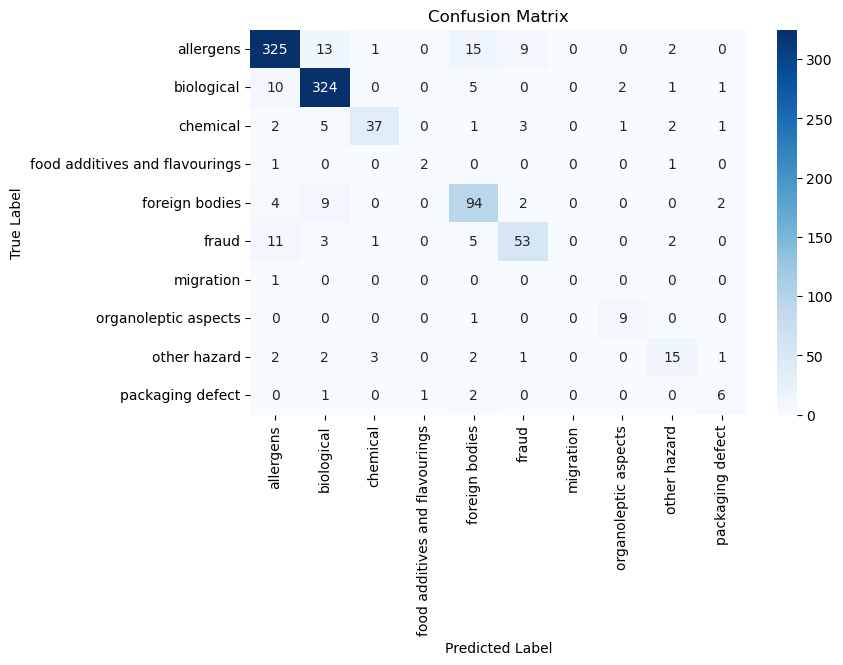

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute Confusion Matrix
cm = confusion_matrix(ground_truths_text, predictions_text, labels=label_encoder.classes_)

# Plot Confusion Matrix
plt.figure(figsize=(8, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

### Product Category

### BERT-Based Product Category Classification

This script fine-tunes a **BERT model** for classifying **food product categories** using PyTorch and Hugging Face Transformers.

---

## **1. Setup & Data Preparation**
- **Import Dependencies**: Loads required libraries (`torch`, `pandas`, `transformers`, `sklearn`, etc.).
- **Set Random Seed**: Ensures reproducibility across experiments.
- **Load Datasets**: Reads the **training, validation, and test** CSV files.
- **Label Encoding**: Converts `product-category` into numerical labels using `LabelEncoder`.
- **Tokenization**: Applies **BERT tokenizer** (`bert-base-uncased`) to the `title` column with **padding & truncation**.
- **Convert to Dataset**: Transforms data into **Hugging Face Dataset** format for PyTorch.

---

## **2. Data Loading & Batching**
- **Dataloaders**: 
  - **Training & Validation**: Batch size = **16** (for efficiency).
  - **Test**: Batch size = **8** (to reduce memory load).
  
---

## **3. Model & Optimization Setup**
- **Define BERT Model**: `BertForSequenceClassification` is loaded with a classifier head.
- **Focal Loss**: Implements **Focal Loss** to handle class imbalance effectively.
- **Optimizer & Scheduler**:
  - **AdamW** optimizer with a **learning rate of 2e-5**.
  - **Linear learning rate scheduler** for controlled training.

---

## **4. Training & Validation**
- **Training Loop**:
  - Iterates over **6 epochs**.
  - Uses **Focal Loss** to compute loss and updates weights.
  - Adjusts learning rate dynamically using a scheduler.
  - Tracks **Training & Validation Loss** across epochs.

- **Validation**:
  - Computes **macro-averaged F1-score** (handles imbalanced classes).
  - Saves best-performing model (`bert_product_category`).

---

## **5. Performance Visualization**
- **Loss Plot**: Compares **Training vs. Validation Loss** over epochs.
- **F1 Score Progression**: Tracks **Validation F1-score** over epochs.

---

## **6. Model Evaluation on Test Data**
- **Inference**: Generates predictions for **test data**.
- **Classification Report**:
  - Computes **Precision, Recall, and F1-score** for each product category.
  - Handles cases with no predictions (`zero_division=0`).
  - Converts numerical labels back to **product category names**.

Map:   0%|          | 0/5082 [00:00<?, ? examples/s]

Map:   0%|          | 0/565 [00:00<?, ? examples/s]

Map:   0%|          | 0/997 [00:00<?, ? examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  0%|          | 0/1908 [00:00<?, ?it/s]

Epoch 1 | Train Loss: 1.5283 | Val Loss: 0.8836 | F1 Score: 0.4207
Epoch 2 | Train Loss: 0.6937 | Val Loss: 0.6421 | F1 Score: 0.5764
Epoch 3 | Train Loss: 0.4374 | Val Loss: 0.6072 | F1 Score: 0.6557
Epoch 4 | Train Loss: 0.2972 | Val Loss: 0.6105 | F1 Score: 0.6428
Epoch 5 | Train Loss: 0.2284 | Val Loss: 0.6043 | F1 Score: 0.6425
Epoch 6 | Train Loss: 0.1886 | Val Loss: 0.6084 | F1 Score: 0.6440


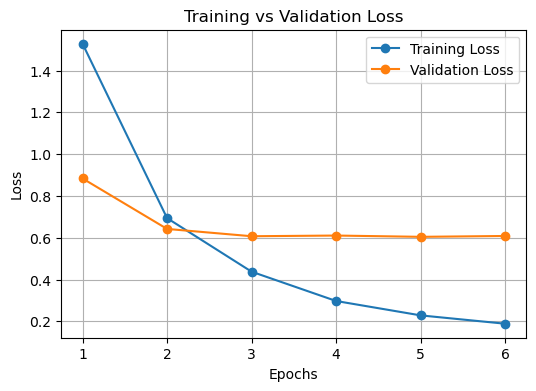

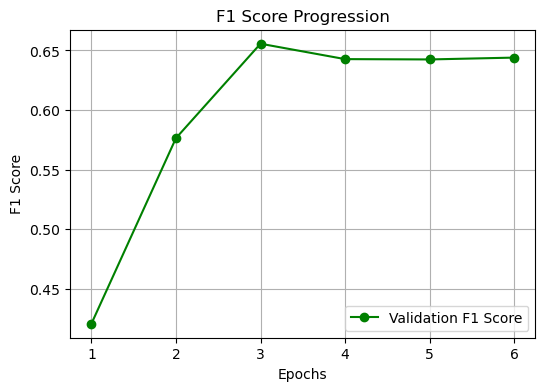

                                                   precision    recall  f1-score   support

                              alcoholic beverages       0.94      1.00      0.97        16
                      cereals and bakery products       0.77      0.75      0.76       121
     cocoa and cocoa preparations, coffee and tea       0.77      0.86      0.81        42
                                    confectionery       0.61      0.52      0.56        33
dietetic foods, food supplements, fortified foods       0.62      0.77      0.69        26
                                    fats and oils       1.00      0.67      0.80         6
                   food additives and flavourings       0.00      0.00      0.00         4
                            fruits and vegetables       0.74      0.73      0.73       103
                                 herbs and spices       0.58      0.70      0.64        20
                            honey and royal jelly       0.00      0.00      0.00         

In [38]:
import torch
import pandas as pd
import numpy as np
import random
from torch.utils.data import DataLoader
from transformers import BertTokenizer, BertForSequenceClassification, AdamW, get_scheduler
from datasets import Dataset
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score, classification_report
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

# Set seed for reproducibility
SEED = 42
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
np.random.seed(SEED)
random.seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Load Data
train_df = pd.read_csv('incidents_train.csv')
valid_df = pd.read_csv('incidents_valid.csv')
test_df = pd.read_csv('incidents_test.csv')

# Define the label column (Product Category)
label_column = 'product-category'

# Tokenizer
MODEL_NAME = 'bert-base-uncased'
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)

def tokenize_function(examples):
    return tokenizer(examples['title'], padding='max_length', truncation=True, max_length=64)

# Label Encoding
label_encoder = LabelEncoder()
train_df['label'] = label_encoder.fit_transform(train_df[label_column])
valid_df['label'] = label_encoder.transform(valid_df[label_column])
test_df['label'] = label_encoder.transform(test_df[label_column])

# Convert to HuggingFace Dataset
def prepare_dataset(df):
    dataset = Dataset.from_pandas(df)
    dataset = dataset.map(tokenize_function, batched=True)
    dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
    return dataset

train_dataset = prepare_dataset(train_df)
valid_dataset = prepare_dataset(valid_df)
test_dataset = prepare_dataset(test_df)

# DataLoaders
train_loader = DataLoader(train_dataset, shuffle=True, batch_size=16)
valid_loader = DataLoader(valid_dataset, batch_size=16)
test_loader = DataLoader(test_dataset, batch_size=8)

# Define Focal Loss
class FocalLoss(torch.nn.Module):
    def __init__(self, gamma=2, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.gamma = gamma
        self.ce_loss = torch.nn.CrossEntropyLoss(reduction='none')
        self.reduction = reduction

    def forward(self, logits, targets):
        ce_loss = self.ce_loss(logits, targets)
        p_t = torch.exp(-ce_loss)
        focal_weight = (1 - p_t) ** self.gamma
        focal_loss = focal_weight * ce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        return focal_loss

# Load BERT Model
model = BertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=len(label_encoder.classes_), ignore_mismatched_sizes=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Optimizer & Scheduler
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)
num_epochs = 6
num_training_steps = num_epochs * len(train_loader)
lr_scheduler = get_scheduler("linear", optimizer=optimizer, num_warmup_steps=0, num_training_steps=num_training_steps)

# Initialize Focal Loss
criterion = FocalLoss(gamma=2)

# Track loss and F1-score for visualization
train_losses = []
val_losses = []
f1_scores = []

# Training Loop
model.train()
progress_bar = tqdm(range(num_training_steps))

for epoch in range(num_epochs):
    total_loss = 0
    model.train()
    
    for batch in train_loader:
        batch = {k: v.to(device) for k, v in batch.items() if k in ['input_ids', 'attention_mask', 'label']}
        outputs = model(input_ids=batch['input_ids'], attention_mask=batch['attention_mask'])
        loss = criterion(outputs.logits, batch['label'])  
        loss.backward()
        optimizer.step()
        lr_scheduler.step()
        optimizer.zero_grad()
        progress_bar.update(1)
        total_loss += loss.item()
    
    avg_train_loss = total_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Validation
    model.eval()
    val_loss = 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in valid_loader:
            batch = {k: v.to(device) for k, v in batch.items() if k in ['input_ids', 'attention_mask', 'label']}  # FIXED HERE
            outputs = model(input_ids=batch['input_ids'], attention_mask=batch['attention_mask'])
            loss = criterion(outputs.logits, batch['label'])  # FIXED HERE

            val_loss += loss.item()
            preds = torch.argmax(outputs.logits, dim=-1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(batch['label'].cpu().numpy())

    avg_val_loss = val_loss / len(valid_loader)
    val_losses.append(avg_val_loss)

    f1 = f1_score(all_labels, all_preds, average='macro')
    f1_scores.append(f1)

    print(f"Epoch {epoch+1} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | F1 Score: {f1:.4f}")

model.save_pretrained("bert_product_category")
np.save("bert_product_category/label_encoder.npy", label_encoder.classes_)

# Plot Training vs Validation Loss
plt.figure(figsize=(6, 4))
plt.plot(range(1, num_epochs + 1), train_losses, label="Training Loss", marker='o')
plt.plot(range(1, num_epochs + 1), val_losses, label="Validation Loss", marker='o')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid()
plt.show()

# Plot F1 Score over Epochs
plt.figure(figsize=(6, 4))
plt.plot(range(1, num_epochs + 1), f1_scores, label="Validation F1 Score", marker='o', color='green')
plt.xlabel("Epochs")
plt.ylabel("F1 Score")
plt.title("F1 Score Progression")
plt.legend()
plt.grid()
plt.show()

# Classification Report on Test Data
model.eval()
total_predictions = []
with torch.no_grad():
    for batch in test_loader:
        batch = {k: v.to(device) for k, v in batch.items() if k in ['input_ids', 'attention_mask']}
        outputs = model(**batch)
        predictions = torch.argmax(outputs.logits, dim=-1)
        total_predictions.extend([p.item() for p in predictions])


# Decode predicted labels
predicted_labels_product = label_encoder.inverse_transform(total_predictions)
gold_labels_product = label_encoder.inverse_transform(test_df['label'].values)

# Print classification report
print(classification_report(gold_labels_product, predicted_labels_product, zero_division=0))

## ST1 Evaluation

In [37]:
import torch
import pandas as pd
import numpy as np
from torch.utils.data import DataLoader
from transformers import BertTokenizer, BertForSequenceClassification
from datasets import Dataset
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score
import os

# Define the compute_score function
def compute_score(hazards_true, products_true, hazards_pred, products_pred):
    # compute f1 for hazards:
    f1_hazards = f1_score(
        hazards_true,
        hazards_pred,
        average='macro'
    )
    # compute f1 for products on examples where hazards were predicted correctly:
    correct_idx = hazards_pred == hazards_true
    if correct_idx.sum() > 0:
        f1_products = f1_score(
            products_true[correct_idx],
            products_pred[correct_idx],
            average='macro'
        )
    else:
        f1_products = 0.0
    return (f1_hazards + f1_products) / 2.

def load_label_encoder(path):
    classes = np.load(path, allow_pickle=True)
    le = LabelEncoder()
    le.classes_ = classes
    return le

def tokenize_function(examples, tokenizer, max_length=64):
    return tokenizer(examples['title'], padding='max_length', truncation=True, max_length=max_length)

def main():
    # Device configuration
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Load the test data (ensure the CSV has columns "title", "hazard-category" and "product-category")
    test_csv_path = 'incidents_test.csv'
    if not os.path.exists(test_csv_path):
        raise FileNotFoundError(f"Test CSV file not found at: {test_csv_path}")
    test_df = pd.read_csv(test_csv_path)

    # Load the saved models for hazards and products
    hazards_model = BertForSequenceClassification.from_pretrained("bert_hazard_category")
    product_model = BertForSequenceClassification.from_pretrained("bert_product_category")
    hazards_model.to(device)
    product_model.to(device)
    hazards_model.eval()
    product_model.eval()

    # Load the corresponding label encoders
    hazards_le = load_label_encoder("bert_hazard_category/label_encoder.npy")
    product_le = load_label_encoder("bert_product_category/label_encoder.npy")

    # Initialize tokenizer (assuming same model architecture)
    MODEL_NAME = 'bert-base-uncased'
    tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)

    # Create a HuggingFace Dataset from the test dataframe and tokenize it.
    test_dataset = Dataset.from_pandas(test_df)
    test_dataset = test_dataset.map(lambda x: tokenize_function(x, tokenizer), batched=True)
    test_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask'])
    test_loader = DataLoader(test_dataset, batch_size=16)

    # Store predictions for hazards and products
    hazards_preds = []
    products_preds = []

    with torch.no_grad():
        for batch in test_loader:
            # Move batch to device
            batch = {k: v.to(device) for k, v in batch.items()}
            # Hazards predictions
            outputs_hazards = hazards_model(input_ids=batch['input_ids'],
                                             attention_mask=batch['attention_mask'])
            batch_hazards_preds = torch.argmax(outputs_hazards.logits, dim=-1)
            hazards_preds.extend(batch_hazards_preds.cpu().numpy())
            # Product predictions
            outputs_products = product_model(input_ids=batch['input_ids'],
                                             attention_mask=batch['attention_mask'])
            batch_products_preds = torch.argmax(outputs_products.logits, dim=-1)
            products_preds.extend(batch_products_preds.cpu().numpy())

    # Convert ground truth labels using the saved label encoders
    hazards_true = hazards_le.transform(test_df["hazard-category"])
    products_true = product_le.transform(test_df["product-category"])

    # Convert predictions to numpy arrays for computation
    hazards_preds = np.array(hazards_preds)
    products_preds = np.array(products_preds)
    hazards_true = np.array(hazards_true)
    products_true = np.array(products_true)

    # Compute and print the ST1 evaluation score
    score = compute_score(hazards_true, products_true, hazards_preds, products_preds)
    print("Evaluation Score (ST1): {:.4f}".format(score))

if __name__ == "__main__":
    main()

Map:   0%|          | 0/997 [00:00<?, ? examples/s]

Evaluation Score (ST1): 0.6382


In [52]:
import pandas as pd
import torch
from transformers import BertTokenizer, BertForSequenceClassification
import numpy as np
from datasets import Dataset
from torch.utils.data import DataLoader
import zipfile

# Load test data
test_df = pd.read_csv('incidents_test.csv')

# Define label columns
hazard_label_column = 'hazard-category'
product_label_column = 'product-category'

# Load tokenizers and models
MODEL_NAME_HAZARD = "bert_hazard_category"
MODEL_NAME_PRODUCT = "bert_product_category"

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
hazard_model = BertForSequenceClassification.from_pretrained(MODEL_NAME_HAZARD)
product_model = BertForSequenceClassification.from_pretrained(MODEL_NAME_PRODUCT)

# Load Label Encoders
hazard_label_encoder = np.load(f"{MODEL_NAME_HAZARD}/label_encoder.npy", allow_pickle=True)
product_label_encoder = np.load(f"{MODEL_NAME_PRODUCT}/label_encoder.npy", allow_pickle=True)

# Convert test data to dataset
def tokenize_function(examples):
    return tokenizer(examples['title'], padding='max_length', truncation=True, max_length=64)

def prepare_dataset(df):
    dataset = Dataset.from_pandas(df)
    dataset = dataset.map(tokenize_function, batched=True)
    dataset.set_format(type='torch', columns=['input_ids', 'attention_mask'])
    return dataset

test_dataset = prepare_dataset(test_df)
test_loader = DataLoader(test_dataset, batch_size=8)

# Inference Function
def predict_category(model, label_encoder, test_loader):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()
    total_predictions = []
    
    with torch.no_grad():
        for batch in test_loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            predictions = torch.argmax(outputs.logits, dim=-1)
            total_predictions.extend(predictions.cpu().numpy())
    
    return label_encoder[total_predictions]

# Get predictions
hazard_preds_labels = predict_category(hazard_model, hazard_label_encoder, test_loader)
product_preds_labels = predict_category(product_model, product_label_encoder, test_loader)

# Create submission dataframe
submission_df = pd.DataFrame({
    'index': test_df.index,
    'hazard-category': hazard_preds_labels,
    'product-category': product_preds_labels
})

# Save to CSV
submission_filename = "submission_ST1.csv"
submission_df.to_csv(submission_filename, index=False)

# Zip the submission file
zip_filename = "submission_ST1.zip"
with zipfile.ZipFile(zip_filename, 'w') as zipf:
    zipf.write(submission_filename)

print(f"Submission file {submission_filename} created and zipped as {zip_filename}.")


Map:   0%|          | 0/997 [00:00<?, ? examples/s]

Submission file submission_ST1.csv created and zipped as submission_dual_category.zip.


## ST2

In [49]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
import zipfile

# Load Data
train_df = pd.read_csv('incidents_train.csv')
valid_df = pd.read_csv('incidents_valid.csv')
test_df = pd.read_csv('incidents_test.csv')

# Define target columns
hazard_column = 'hazard'
product_column = 'product'

# Combine all datasets to fit LabelEncoder on full data
full_data = pd.concat([train_df, valid_df, test_df])

# Encode labels (fit on all data first)
hazard_encoder = LabelEncoder()
hazard_encoder.fit(full_data[hazard_column])
train_df['hazard_label'] = hazard_encoder.transform(train_df[hazard_column])
valid_df['hazard_label'] = hazard_encoder.transform(valid_df[hazard_column])
test_df['hazard_label'] = hazard_encoder.transform(test_df[hazard_column])

product_encoder = LabelEncoder()
product_encoder.fit(full_data[product_column])
train_df['product_label'] = product_encoder.transform(train_df[product_column])
valid_df['product_label'] = product_encoder.transform(valid_df[product_column])
test_df['product_label'] = product_encoder.transform(test_df[product_column])

# Feature Engineering
text_features = ['title', 'text']
categorical_features = ['year', 'month', 'day', 'country']

preprocessor = ColumnTransformer([
    ('tfidf', TfidfVectorizer(max_features=5000), 'title'),
    ('onehot', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

# Train Random Forest for Hazard Prediction
hazard_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=200, random_state=42))
])

hazard_pipeline.fit(train_df, train_df['hazard_label'])

# Train Random Forest for Product Prediction
product_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=200, random_state=42))
])

product_pipeline.fit(train_df, train_df['product_label'])

# Predictions
hazard_preds = hazard_pipeline.predict(test_df)
product_preds = product_pipeline.predict(test_df)

# Convert predictions to original labels
hazard_preds_labels = hazard_encoder.inverse_transform(hazard_preds)
product_preds_labels = product_encoder.inverse_transform(product_preds)

# Compute Evaluation Score
def compute_score(hazards_true, products_true, hazards_pred, products_pred):
    f1_hazards = f1_score(hazards_true, hazards_pred, average='macro')
    correct_idx = hazards_pred == hazards_true
    f1_products = f1_score(products_true[correct_idx], products_pred[correct_idx], average='macro') if correct_idx.sum() > 0 else 0.0
    return (f1_hazards + f1_products) / 2.0

hazard_true_labels = test_df['hazard_label'].values
product_true_labels = test_df['product_label'].values
st2_score = compute_score(hazard_true_labels, product_true_labels, hazard_preds, product_preds)

# Create Submission File
submission_df = pd.DataFrame({
    'index': test_df.index,
    'hazard': hazard_preds_labels,
    'product': product_preds_labels
})

submission_filename = "submission_ST2.csv"
submission_df.to_csv(submission_filename, index=False)

# Zip the submission file
zip_filename = "submission_ST2.zip"
with zipfile.ZipFile(zip_filename, 'w') as zipf:
    zipf.write(submission_filename)

print(f"Submission file {submission_filename} created and zipped as {zip_filename}.")
print(f"Evaluation Score (ST2): {st2_score:.4f}")

Submission file submission_ST2.csv created and zipped as submission_ST2.zip.
Evaluation Score (ST2): 0.3140
